<a href="https://colab.research.google.com/github/TKcodes-bit/ML/blob/main/Thomas_tensorflow_keras_part2_functional_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to TensorFlow & Keras — Part 2
### The Functional API, branching models, and multi-input problems

Picking up right where Part 1 left off. There, you built and trained
`digit_classifier` — a single-input, single-output stack — using the
Sequential API, and were asked to imagine a case where Sequential
wouldn't be enough. This notebook builds that case for real.

### Code rules for this notebook
1. Keep all your imports in the next cell.
2. Give variables names that say what they hold.
3. Add type hints to every function you write.
4. Every model must go through `train_and_evaluate()` once you've written it below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()
X_train = X_train_raw.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test_raw.reshape(-1, 28 * 28).astype("float32") / 255.0

print(f"X_train shape: {X_train.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (60000, 784)


## Step 1: The Functional API, syntax first

Recap: in the Functional API you don't hand Keras a list. You create
an `Input`, then call each layer directly on a tensor, passing the
result forward yourself. The model is then defined by which tensors
are its inputs and outputs.

📖 [The Functional API (Keras docs)](https://www.tensorflow.org/guide/keras/functional_api)

In [ ]:
inputs = keras.Input(shape=(784,))
x = layers.Dense(64, activation="relu")(inputs)  # HINT: First hidden layer takes inputs and extract 64 features
x = layers.Dropout(0.2)(x)  # HINT: exerts a 20% dropout tensor and x to limit overfitting
outputs = layers.Dense(10, activation="softmax")(x)  # HINT: output layer transforms x into 10 probabilit layers

functional_classifier = keras.Model(inputs= inputs, outputs= outputs)  # HINT: Define entry and exit points
functional_classifier.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
keras.utils.plot_model(functional_classifier, show_shapes=True, show_layer_names=True)

**🧠 Your turn:** Compare this `summary()` to `digit_classifier`'s from
Part 1. Same layers, same shapes — what's actually different between
the two versions?

_Write your answer here:_ The functional Variant exposes the input layer as a standalone step in the summary table whereas the sequential model hids it within the first hidden dense layer

## Step 2: One function you'll reuse for the rest of this notebook

Same principle as before: write it once, reuse it for every model
below.

In [ ]:
def train_and_evaluate(
    model: keras.Model,
    x: Any,
    y: Any,
    epochs: int = 30,
    batch_size: int = 128,
) -> Dict[str, Any]:
    # Compiles-agnostic: assumes `model` is already compiled.
    # Trains with a 10% validation split and early stopping, then
    # reports how it did. Reused for every model in this notebook.
    #
    # x, y: training inputs and labels. x can be a single array, or a
    # list of arrays for models with more than one input.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True
    )

    # HINT: call model.fit(...) with x, y, validation_split=0.1, epochs,
    # batch_size, callbacks=[early_stopping], verbose=0 -- store the result
    history = model.fit (
        x,
        y,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0 #run silently to keep the notebook clean

    )
    return {
        "history": history.history,
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "epochs_run": len(history.history["loss"]),
    }

In [ ]:
functional_classifier.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
functional_results = train_and_evaluate(functional_classifier, X_train, y_train)
print(f"Final validation accuracy: {functional_results['final_val_accuracy']:.4f}")

Final validation accuracy: 0.9785


## Step 3: A real multi-input problem — image + text

Here's a genuine reason to want two separate inputs. Picture a bank's
check-processing pipeline: each check has a handwritten digit (the
image) for the amount, *and* a separate typed field where the amount
was also written out in words — a real cross-checking feature actual
check-scanning systems use. The catch: that typed field gets OCR'd
automatically, and OCR sometimes misreads it.

Below, we simulate exactly that: a short text "hint" that agrees with
the true digit most of the time, but is deliberately wrong some of
the time — just like a noisy OCR read would be. (The simulation code
is given below — it's not the point of this step. What matters is
what comes next: building a model that actually takes both inputs.)

`Sequential` can't take two independent inputs like this. The
Functional API can: one `Input` for the image, one `Input` for the
text token, each with its own layers, merged with `Concatenate`
before the final prediction.

📖 [Embedding layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) · [Multi-input/output models (Functional API guide)](https://www.tensorflow.org/guide/keras/functional_api#models_with_multiple_inputs_and_outputs) · [Concatenate layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Concatenate)

In [ ]:
DIGIT_WORDS = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
OCR_ERROR_RATE = 0.2  # how often the typed hint disagrees with the true digit

def make_noisy_text_hints(true_labels: np.ndarray, error_rate: float) -> np.ndarray:
    # Simulates an OCR'd text field: returns one word-index per example,
    # matching the true label most of the time, but wrong `error_rate`
    # fraction of the time (a random *different* digit). Not the point
    # of this notebook -- just setup so Step 3 has two real inputs to work with.
    rng = np.random.default_rng(RANDOM_SEED)
    is_wrong = rng.random(len(true_labels)) < error_rate
    random_digit = rng.integers(0, 10, size=len(true_labels))
    return np.where(is_wrong, random_digit, true_labels)

train_text_hints = make_noisy_text_hints(y_train, OCR_ERROR_RATE)
test_text_hints = make_noisy_text_hints(y_test, OCR_ERROR_RATE)

print(f"Example: true digit = {y_train[0]}, typed hint = '{DIGIT_WORDS[train_text_hints[0]]}'")
print(f"Hint agrees with true label {np.mean(train_text_hints == y_train):.1%} of the time")

Example: true digit = 5, typed hint = 'five'
Hint agrees with true label 81.9% of the time


In [ ]:
image_input = keras.Input(shape=(784,), name="image")
text_input = keras.Input(shape=(1,), name="text_hint")

image_branch = layers.Dense(64, activation="relu")(image_input)

text_branch = layers.Embedding(input_dim= 10 , output_dim=8)(text_input)  # HINT: 10 possible digit words
text_branch = layers.Flatten()(text_branch)

combined = layers.Concatenate()([image_branch, text_branch])  # HINT: merge the processed text branch with the image branch
outputs = layers.Dense(10, activation="softmax")(combined)

fusion_model = keras.Model(inputs=[image_input, text_input], outputs=outputs)
fusion_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_hint           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 784)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │         80 │ text_hint[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     50,240 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │        730 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,050 (199.41 KB)

 Trainable params: 51,050 (199.41 KB)

 Non-trainable params: 0 (0.00 B)

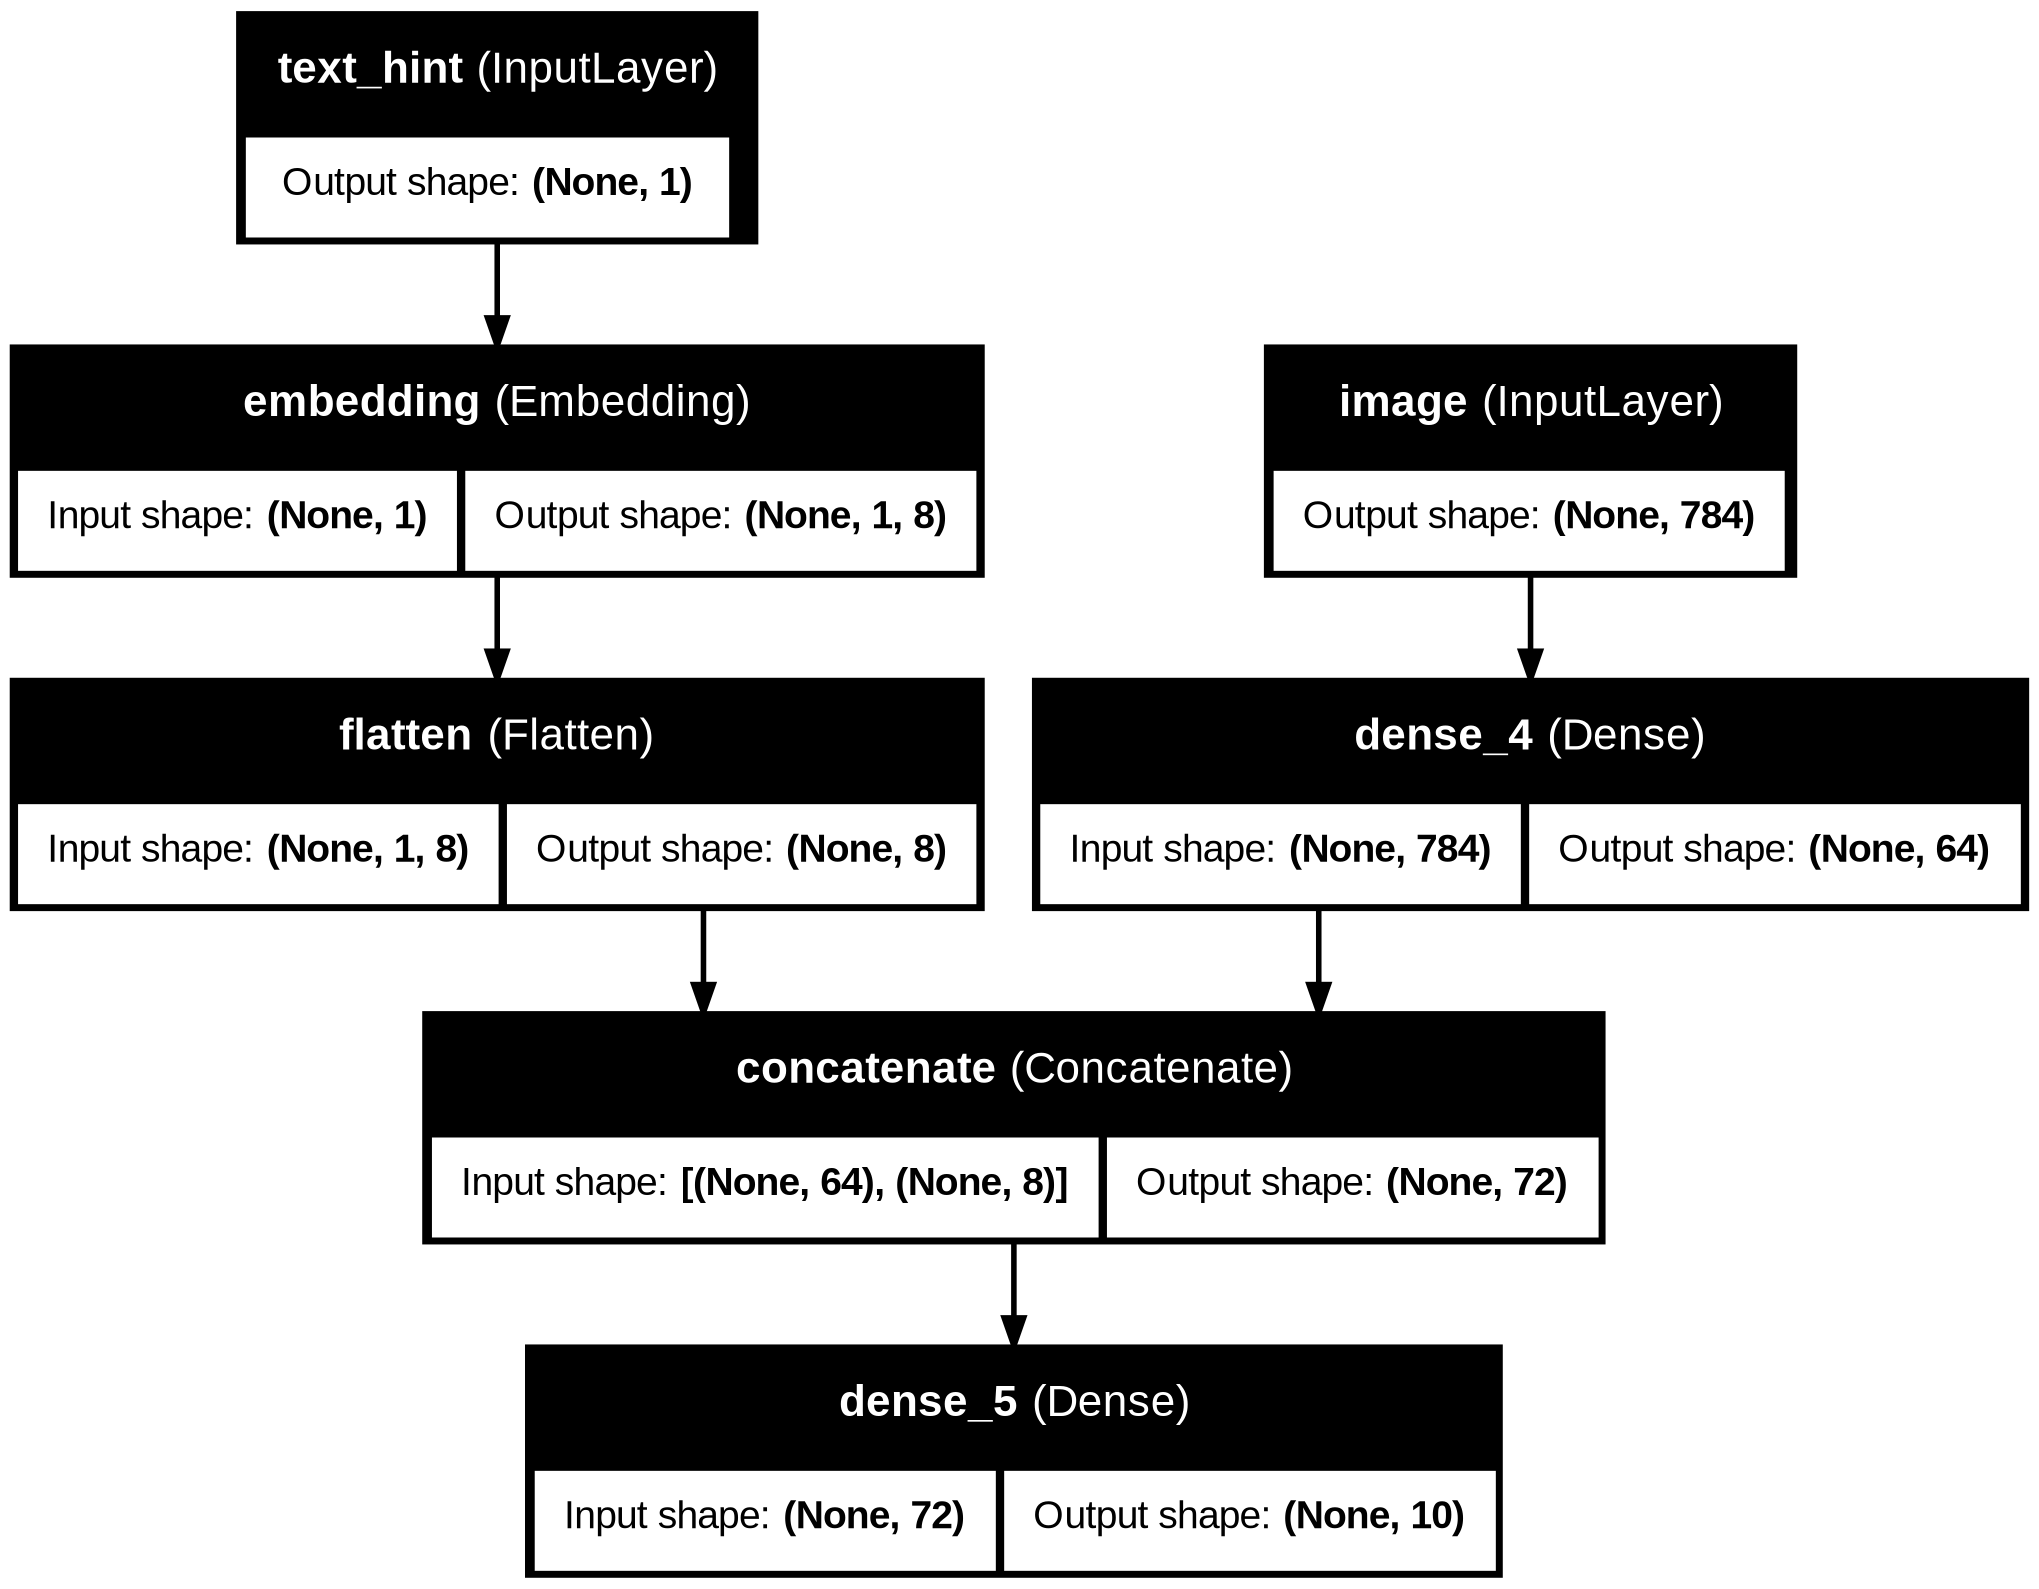

In [ ]:
# A text summary lists layers top to bottom, but doesn't show branching.
# For a multi-input model, the picture makes the two-branches-merging
# shape obvious in a way the text summary above doesn't.
keras.utils.plot_model(fusion_model, show_shapes=True, show_layer_names=True)

In [ ]:
fusion_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fusion_results = train_and_evaluate(fusion_model, x=[X_train, train_text_hints], y=y_train)
print(f"Combined (image + text) validation accuracy: {fusion_results['final_val_accuracy']:.4f}")

Combined (image + text) validation accuracy: 0.9842


**🧠 Your turn:** The text hint alone agrees with the true label about
80% of the time (since `OCR_ERROR_RATE = 0.2`), so a model that only
looked at the text could never beat ~80% accuracy. Did combining it
with the image push accuracy above that ceiling? What does that tell
you about combining two imperfect signals versus trusting either one
alone?

_Write your answer here:_ Indeed combining the image with text hint pushed the accuracy to 98.42 way past the 80% text_on;y ceilling

## Step 4: Branching and merging, more generally

Multiple inputs is one use of the Functional API's flexibility, but
the bigger idea is that a model is really just a **graph of layers**
— data can split into parallel branches and merge back together, even
with a single input. Below, the same image feeds two separate `Dense`
branches of different sizes, and their outputs are concatenated
before the final layer.

📖 [Manipulating complex graph topologies (Functional API guide)](https://www.tensorflow.org/guide/keras/functional_api#manipulate_complex_graph_topologies)

In [ ]:
image_input = keras.Input(shape=(784,))

wide_branch = layers.Dense(128, activation="relu")(image_input)
narrow_branch = layers.Dense(16, activation="relu")(image_input)  # HINT: Feeds the same input image into the narrow branch

merged = layers.Concatenate()([wide_branch, narrow_branch])  # HINT: merges the wide and narrow feature output together
outputs = layers.Dense(10, activation="softmax")(merged)

branching_model = keras.Model(inputs=image_input, outputs=outputs)
branching_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    100,480 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │     12,560 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 144)       │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      1,450 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,490 (447.23 KB)

 Trainable params: 114,490 (447.23 KB)

 Non-trainable params: 0 (0.00 B)

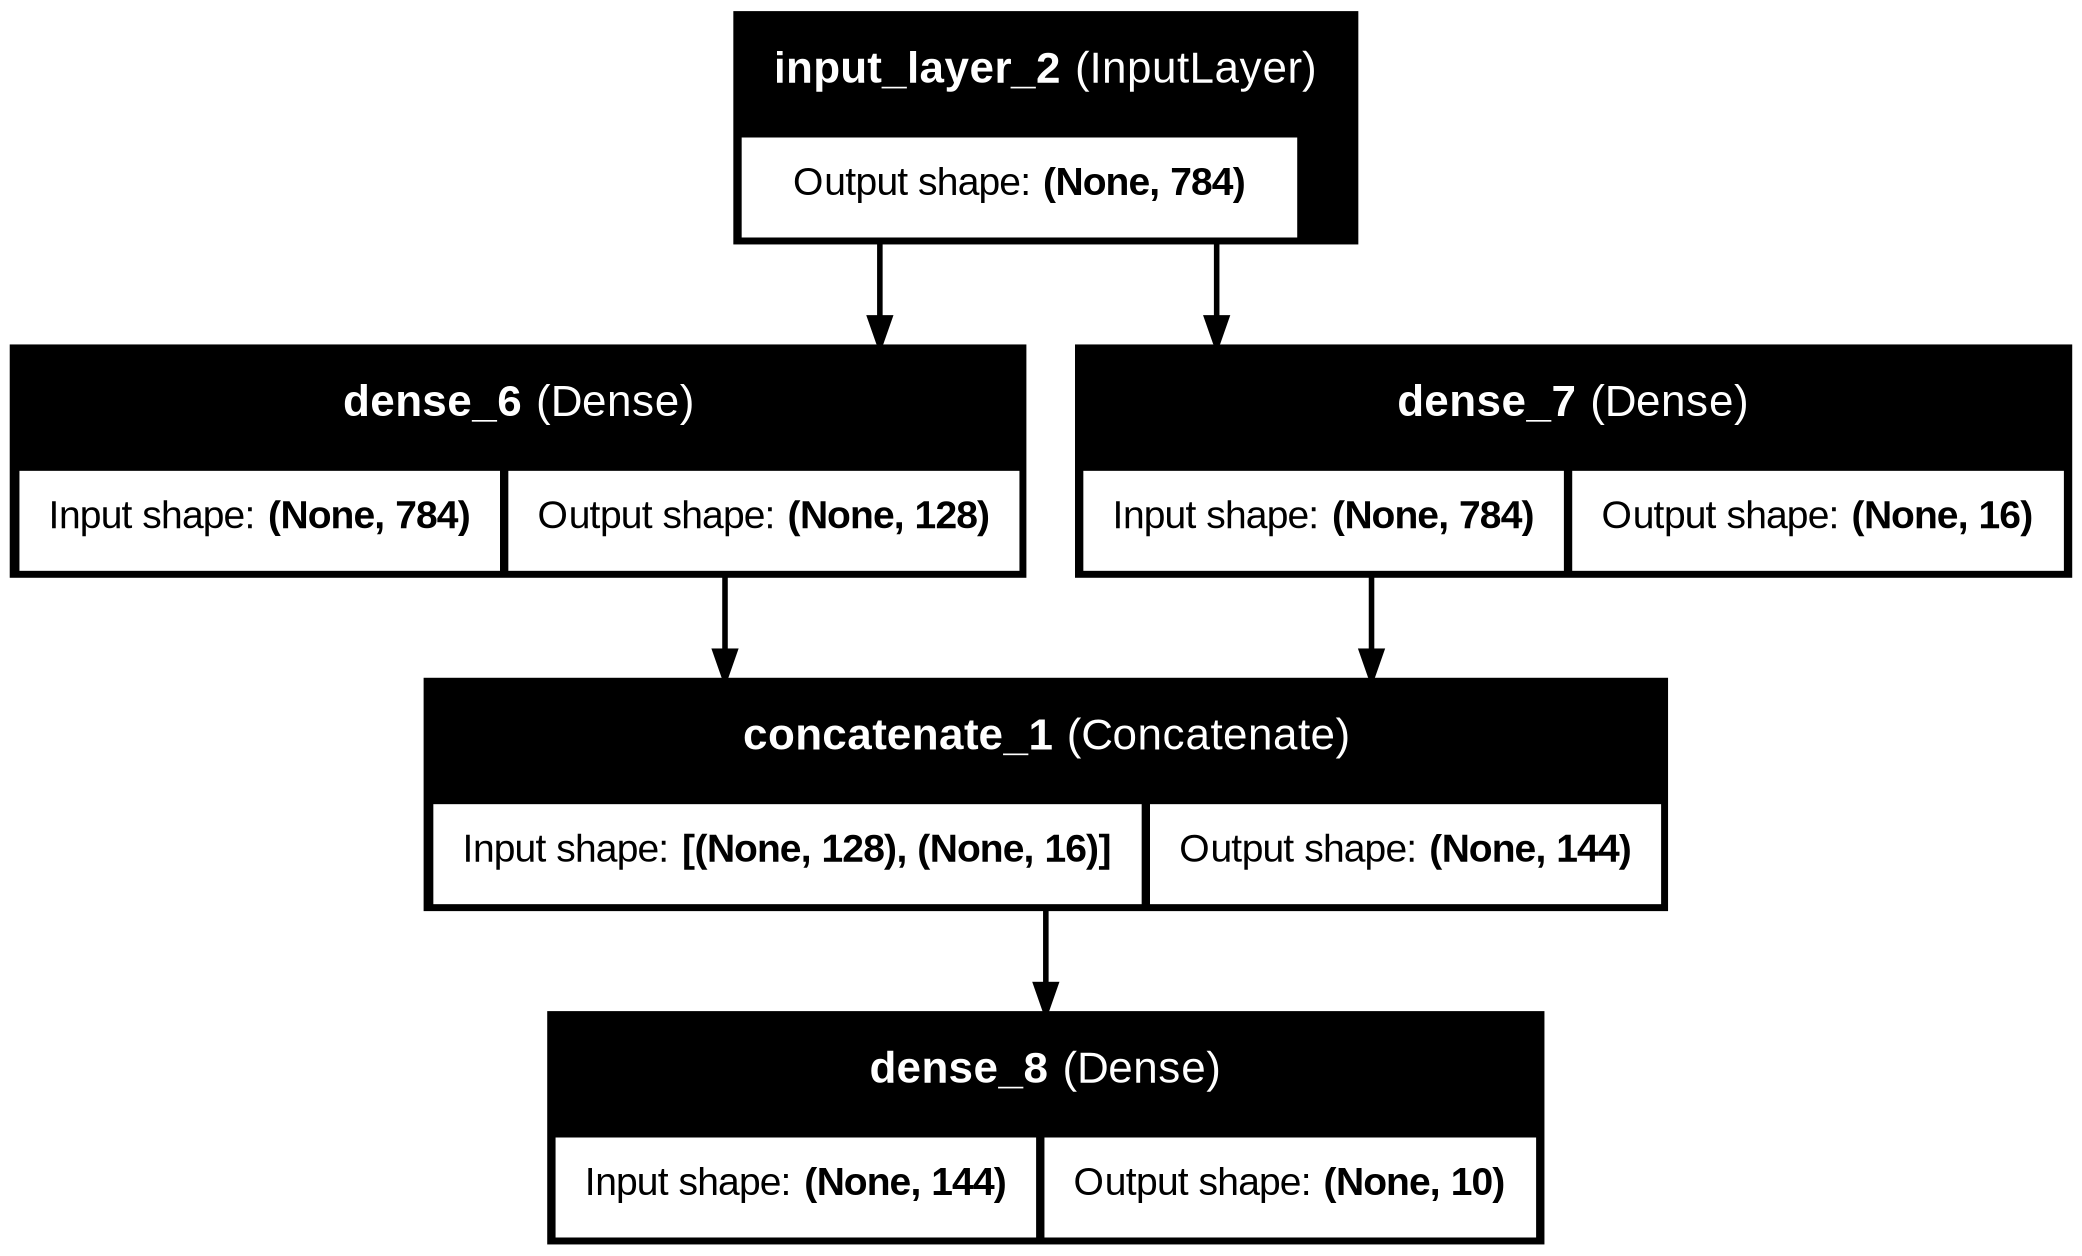

In [ ]:
keras.utils.plot_model(branching_model, show_shapes=True, show_layer_names=True)

In [ ]:
branching_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
branching_results = train_and_evaluate(branching_model, X_train, y_train)
print(f"Final validation accuracy: {branching_results['final_val_accuracy']:.4f}")

Final validation accuracy: 0.9785


**🧠 Your turn:** Could you build this exact branching model with
Sequential? Why or why not?

_Write your answer here:_ No because sequential can only stack layers in a single straight line meaning it cannot handle split data.

## Wrap-up

**Final question:** across this notebook you've now built the same
basic classifier three different ways — the plain Functional
equivalent of Part 1's model, a two-input version, and a branching
version. What's the one thing that stayed identical in every version,
and what changed?

_Write your answer here:_ The classification output layer remain the same while the input architecture and internal feature-extraction pathways changed.

## Going further

| Idea | What it roughly controls |
|---|---|
| `Conv2D` + `MaxPooling2D` | Convolutional layers — look at local patterns instead of a flat vector; usually the biggest jump on image data |
| Model subclassing | A third way to build models, writing the forward pass as regular Python code — more flexible than Functional, more work |
| Shared layers | Reusing the *same* layer object in two places in the graph, so it learns one shared representation |
| `model.save()` / `load_model()` | Saving a trained model to disk and reloading it later |

📖 [Convolutional layers (Keras image classification tutorial)](https://www.tensorflow.org/tutorials/images/cnn)